
# Real-World Option Pricing with `yfinance`
## European vs American, dividend stocks, Black-Scholes, 1-step binomial, multi-step CRR, and risk mitigation

This notebook applies classroom option-pricing ideas to a real trading workflow using `yfinance`.

It covers:

- stock and option-chain data from `yfinance`
- dividend-paying stocks
- volatility estimation from price history
- pricing with:
  - **Black-Scholes** (European)
  - **1-step binomial**
  - **multi-step CRR binomial**
  - **American option pricing** via binomial tree
- comparing model values to market prices
- translating results into **business explanations**
- adding a **risk-mitigation layer** before a trade

> This notebook is for learning and analysis. It does not guarantee profits and it is not personalized investment advice.

---

## Practical interpretation

You cannot control the stock price.  
What you *can* control is:

- strike
- expiry
- call vs put
- how much premium you are willing to lose
- position size
- whether the trade thesis matches the contract



## How to use this notebook

1. Run the install/import cells.
2. Set the ticker and option settings in **User Inputs**.
3. Download price and option-chain data from `yfinance`.
4. Select one contract.
5. Review:
   - market quote
   - Black-Scholes value
   - 1-step binomial value
   - multi-step European CRR value
   - multi-step American CRR value
   - early-exercise premium
   - break-even and max loss
   - business explanation
   - risk-mitigation checks

This notebook is built for **long call** and **long put** analysis.


In [ ]:
# If needed, uncomment:
# !pip install yfinance scipy pandas numpy matplotlib

In [1]:
import math
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm
from scipy.optimize import brentq

import yfinance as yf

## User Inputs

In [2]:
# -------- User inputs --------
ticker = "KO"                 # Try: KO, AAPL, MSFT, JPM, etc.
option_type = "call"          # "call" or "put"
contracts = 1                 # Number of option contracts
risk_budget_usd = 200         # Maximum premium you are comfortable losing
manual_risk_free_rate = 0.04  # User-entered annual rate
hist_vol_lookback_days = 252  # 1 trading year
crr_steps = 200               # Multi-step CRR tree depth
target_expiry = None          # Example: "2026-06-19". If None, notebook picks the first listed expiry
target_strike = None          # Example: 275. If None, notebook picks nearest strike to spot
use_mid_price = True          # Use bid/ask midpoint if possible; else fallback to lastPrice
plot_price_range_pct = 0.20   # +/- 20% around current spot for scenario chart


## Core formulas

### 1) Black-Scholes with continuous dividend yield

For a stock with continuous dividend yield \(q\):

$$
d_1 = \frac{\ln(S/K) + (r - q + \tfrac{1}{2}\sigma^2)T}{\sigma\sqrt{T}}
$$

$$
d_2 = d_1 - \sigma\sqrt{T}
$$

European call:

$$
C = Se^{-qT}N(d_1) - Ke^{-rT}N(d_2)
$$

European put:

$$
P = Ke^{-rT}N(-d_2) - Se^{-qT}N(-d_1)
$$

### 2) 1-step binomial

$$
u = e^{\sigma\sqrt{T}}, \qquad d = \frac{1}{u}
$$

$$
p = \frac{e^{(r-q)T} - d}{u-d}
$$

$$
V_0 = e^{-rT}\left[pV_u + (1-p)V_d\right]
$$

### 3) Multi-step CRR binomial

With \(\Delta t = T/N\),

$$
u = e^{\sigma\sqrt{\Delta t}}, \qquad d = \frac{1}{u}
$$

$$
p = \frac{e^{(r-q)\Delta t} - d}{u-d}
$$

At each node:

- European option: only continuation value
- American option: max(exercise value, continuation value)

### Why this matters in real life

- **Black-Scholes** is fast and intuitive, but it is a **European** model.
- **American-style** equity options can be exercised early, so the **CRR tree** is a practical real-world tool.
- For **dividend-paying stocks**, American calls can differ from European calls.


In [4]:
@dataclass
class OptionResult:
    price: float
    delta: float = np.nan
    gamma: float = np.nan
    theta_per_day: float = np.nan
    vega: float = np.nan
    rho: float = np.nan


def bs_price(S, K, T, r, q, sigma, option_type="call"):
    if T <= 0:
        return max(S - K, 0.0) if option_type == "call" else max(K - S, 0.0)

    if sigma <= 0:
        forward = S * math.exp((r - q) * T)
        disc = math.exp(-r * T)
        payoff = max(forward - K, 0.0) if option_type == "call" else max(K - forward, 0.0)
        return disc * payoff

    d1 = (math.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * math.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)

    if option_type == "call":
        return S * math.exp(-q * T) * norm.cdf(d1) - K * math.exp(-r * T) * norm.cdf(d2)
    return K * math.exp(-r * T) * norm.cdf(-d2) - S * math.exp(-q * T) * norm.cdf(-d1)


def bs_greeks(S, K, T, r, q, sigma, option_type="call"):
    if T <= 0 or sigma <= 0:
        return OptionResult(price=bs_price(S, K, T, r, q, sigma, option_type))

    d1 = (math.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * math.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)
    pdf_d1 = norm.pdf(d1)

    price = bs_price(S, K, T, r, q, sigma, option_type)
    gamma = math.exp(-q * T) * pdf_d1 / (S * sigma * math.sqrt(T))
    vega = S * math.exp(-q * T) * pdf_d1 * math.sqrt(T) / 100.0

    if option_type == "call":
        delta = math.exp(-q * T) * norm.cdf(d1)
        theta = (
            -S * math.exp(-q * T) * pdf_d1 * sigma / (2 * math.sqrt(T))
            - r * K * math.exp(-r * T) * norm.cdf(d2)
            + q * S * math.exp(-q * T) * norm.cdf(d1)
        ) / 365.0
        rho = K * T * math.exp(-r * T) * norm.cdf(d2) / 100.0
    else:
        delta = math.exp(-q * T) * (norm.cdf(d1) - 1)
        theta = (
            -S * math.exp(-q * T) * pdf_d1 * sigma / (2 * math.sqrt(T))
            + r * K * math.exp(-r * T) * norm.cdf(-d2)
            - q * S * math.exp(-q * T) * norm.cdf(-d1)
        ) / 365.0
        rho = -K * T * math.exp(-r * T) * norm.cdf(-d2) / 100.0

    return OptionResult(price=price, delta=delta, gamma=gamma, theta_per_day=theta, vega=vega, rho=rho)


def implied_volatility(market_price, S, K, T, r, q, option_type="call"):
    if market_price <= 0 or T <= 0:
        return np.nan

    def objective(sig):
        return bs_price(S, K, T, r, q, sig, option_type) - market_price

    try:
        return brentq(objective, 1e-6, 5.0)
    except ValueError:
        return np.nan


def one_step_binomial(S, K, T, r, q, sigma, option_type="call"):
    if T <= 0:
        return max(S - K, 0.0) if option_type == "call" else max(K - S, 0.0)

    u = math.exp(sigma * math.sqrt(T))
    d = 1.0 / u
    p = (math.exp((r - q) * T) - d) / (u - d)

    Su = S * u
    Sd = S * d

    Vu = max(Su - K, 0.0) if option_type == "call" else max(K - Su, 0.0)
    Vd = max(Sd - K, 0.0) if option_type == "call" else max(K - Sd, 0.0)

    return math.exp(-r * T) * (p * Vu + (1 - p) * Vd)


def crr_binomial(S, K, T, r, q, sigma, steps=100, option_type="call", american=False, return_boundary=False):
    if T <= 0:
        intrinsic = max(S - K, 0.0) if option_type == "call" else max(K - S, 0.0)
        if return_boundary:
            return intrinsic, pd.DataFrame()
        return intrinsic

    dt = T / steps
    u = math.exp(sigma * math.sqrt(dt))
    d = 1.0 / u
    disc = math.exp(-r * dt)
    p = (math.exp((r - q) * dt) - d) / (u - d)

    stock_terminal = np.array([S * (u ** j) * (d ** (steps - j)) for j in range(steps + 1)], dtype=float)
    if option_type == "call":
        values = np.maximum(stock_terminal - K, 0.0)
    else:
        values = np.maximum(K - stock_terminal, 0.0)

    exercise_rows = []

    for i in range(steps - 1, -1, -1):
        continuation = disc * (p * values[1:i+2] + (1 - p) * values[0:i+1])

        if american:
            stock_now = np.array([S * (u ** j) * (d ** (i - j)) for j in range(i + 1)], dtype=float)
            if option_type == "call":
                exercise = np.maximum(stock_now - K, 0.0)
            else:
                exercise = np.maximum(K - stock_now, 0.0)

            values = np.maximum(exercise, continuation)

            if return_boundary:
                is_ex = (exercise > continuation + 1e-12) & (exercise > 0)
                if is_ex.any():
                    tmp = pd.DataFrame({
                        "step": i,
                        "node": np.arange(i + 1),
                        "stock_price": stock_now,
                        "exercise_value": exercise,
                        "continuation_value": continuation,
                        "exercise_now": is_ex,
                    })
                    exercise_rows.append(tmp[tmp["exercise_now"]].copy())
        else:
            values = continuation

    if return_boundary:
        boundary = pd.concat(exercise_rows, ignore_index=True) if exercise_rows else pd.DataFrame()
        return float(values[0]), boundary

    return float(values[0])


def estimate_hist_vol(history):
    closes = history["Close"].dropna().copy()
    rets = np.log(closes / closes.shift(1)).dropna()
    return float(rets.std() * np.sqrt(252))


def estimate_dividend_yield(stock, spot):
    q = np.nan
    annual_dividend = np.nan

    try:
        info = stock.info
    except Exception:
        info = {}

    if isinstance(info, dict):
        q = info.get("dividendYield", np.nan)
        annual_dividend = info.get("dividendRate", np.nan)

    if pd.isna(q):
        try:
            divs = stock.dividends
            divs = divs[divs.index >= (pd.Timestamp.today(tz=None) - pd.Timedelta(days=365))]
            annual_dividend = divs.sum() if len(divs) else annual_dividend
        except Exception:
            pass

        if not pd.isna(annual_dividend) and spot > 0:
            q = float(annual_dividend) / float(spot)

    return 0.0 if pd.isna(q) else float(q)


def choose_option_row(df, target_strike=None, spot=None):
    out = df.copy()
    if target_strike is None:
        if spot is None:
            raise ValueError("spot is required if target_strike is None")
        idx = (out["strike"] - spot).abs().idxmin()
    else:
        idx = (out["strike"] - target_strike).abs().idxmin()
    return out.loc[idx].copy()


def clean_market_premium(row, use_mid=True):
    bid = row.get("bid", np.nan)
    ask = row.get("ask", np.nan)
    lastp = row.get("lastPrice", np.nan)

    if use_mid and pd.notna(bid) and pd.notna(ask) and bid > 0 and ask > 0 and ask >= bid:
        return float((bid + ask) / 2.0)
    if pd.notna(lastp) and lastp > 0:
        return float(lastp)
    if pd.notna(bid) and pd.notna(ask) and ask >= bid:
        return float((bid + ask) / 2.0)
    return np.nan


def long_option_payoff_per_share(S_T, K, premium, option_type="call"):
    intrinsic = np.maximum(S_T - K, 0.0) if option_type == "call" else np.maximum(K - S_T, 0.0)
    return intrinsic - premium


def option_trade_metrics(spot, strike, premium_per_share, option_type, contracts):
    if option_type == "call":
        breakeven = strike + premium_per_share
        max_profit = np.inf
    else:
        breakeven = strike - premium_per_share
        max_profit = strike - premium_per_share

    max_loss = premium_per_share * 100 * contracts

    return {
        "breakeven_stock_price_at_expiry": breakeven,
        "max_loss_usd": max_loss,
        "max_profit_per_share": max_profit,
    }


def max_contracts_from_risk_budget(premium_per_share, risk_budget_usd):
    if premium_per_share <= 0:
        return 0
    return int(risk_budget_usd // (premium_per_share * 100))


def make_business_summary(result):
    lines = []
    lines.append(f"Ticker: {result['ticker']}")
    lines.append(f"Selected contract: {result['option_type'].upper()} strike {result['strike']:.2f}, expiry {result['expiry']}")
    lines.append(f"Spot price is {result['spot']:.2f} and market premium is {result['market_premium']:.2f} per share.")
    lines.append(f"Estimated dividend yield used in pricing is {result['dividend_yield']*100:.2f}%.")
    lines.append(f"Historical volatility estimate is {result['sigma_hist']*100:.2f}% annualized.")
    lines.append(f"Time to expiry is {result['T_years']:.3f} years.")

    mispricing_vs_bs = result["market_premium"] - result["bs_price"]
    mispricing_vs_am = result["market_premium"] - result["crr_american_price"]

    if abs(mispricing_vs_bs) < 0.05:
        lines.append("Against Black-Scholes, the market premium is roughly in line with the model.")
    elif mispricing_vs_bs > 0:
        lines.append("Against Black-Scholes, the market premium is richer than the model value.")
    else:
        lines.append("Against Black-Scholes, the market premium is cheaper than the model value.")

    if abs(mispricing_vs_am) < 0.05:
        lines.append("Against the American CRR model, the premium is also roughly aligned.")
    elif mispricing_vs_am > 0:
        lines.append("Against the American CRR model, the contract trades above the model estimate.")
    else:
        lines.append("Against the American CRR model, the contract trades below the model estimate.")

    if result["option_type"] == "call":
        lines.append(f"The expiry break-even is {result['breakeven']:.2f}. The stock must finish above that level at expiry for a long call to profit at expiry.")
    else:
        lines.append(f"The expiry break-even is {result['breakeven']:.2f}. The stock must finish below that level at expiry for a long put to profit at expiry.")

    lines.append(f"With {result['contracts']} contract(s), the maximum premium at risk is about ${result['max_loss_usd']:.2f}.")

    if result["early_exercise_premium"] > 0.02:
        lines.append("The American model is meaningfully above the European model, so early-exercise flexibility has value here.")
    else:
        lines.append("The American model is very close to the European model, so early exercise does not appear very valuable here.")

    lines.append("Business translation: this trade is not only a view on direction, it is a view on direction, timing, and volatility.")
    return "".join(f"- {x}" for x in lines)

## Download stock data and option chain

In [5]:
stock = yf.Ticker(ticker)

history = stock.history(period="1y", auto_adjust=False)
if history.empty:
    raise ValueError("No price history returned. Check ticker or internet connection.")

spot = float(history["Close"].dropna().iloc[-1])
sigma_hist = estimate_hist_vol(history)
dividend_yield = estimate_dividend_yield(stock, spot)

expiries = list(stock.options)
if len(expiries) == 0:
    raise ValueError("No listed expiries found for this ticker.")

expiry = target_expiry if target_expiry is not None else expiries[0]
if expiry not in expiries:
    raise ValueError(f"Chosen expiry {expiry} not found. Available expiries: {expiries[:10]} ...")

chain = stock.option_chain(expiry)
chain_df = chain.calls.copy() if option_type == "call" else chain.puts.copy()
chain_df = chain_df.sort_values("strike").reset_index(drop=True)

selected_row = choose_option_row(chain_df, target_strike=target_strike, spot=spot)
selected_row

contractSymbol               KO260410C00077000
lastTradeDate        2026-04-02 19:59:00+00:00
strike                                    77.0
lastPrice                                 0.68
bid                                       0.66
ask                                       0.72
change                                    0.07
percentChange                        11.475409
volume                                  1735.0
openInterest                              5283
impliedVolatility                     0.200692
inTheMoney                               False
contractSize                           REGULAR
currency                                   USD
Name: 8, dtype: object

## Selected contract and time to expiry

In [6]:
today = pd.Timestamp.today(tz=None).normalize()
expiry_dt = pd.Timestamp(expiry)
T_years = max((expiry_dt - today).days / 365.0, 1 / 365.0)

strike = float(selected_row["strike"])
market_premium = clean_market_premium(selected_row, use_mid=use_mid_price)

selected_contract = pd.DataFrame({
    "field": ["ticker", "option_type", "expiry", "spot", "strike", "bid", "ask", "lastPrice", "market_premium_used", "time_to_expiry_years"],
    "value": [
        ticker,
        option_type,
        expiry,
        spot,
        strike,
        selected_row.get("bid", np.nan),
        selected_row.get("ask", np.nan),
        selected_row.get("lastPrice", np.nan),
        market_premium,
        T_years,
    ]
})
selected_contract

,field,value
0,ticker,KO
1,option_type,call
2,expiry,2026-04-10
3,spot,76.720001
4,strike,77.0
5,bid,0.66
6,ask,0.72
7,lastPrice,0.68
8,market_premium_used,0.69
9,time_to_expiry_years,0.013699


## Price the selected option with multiple models

In [7]:
sigma = sigma_hist
r = manual_risk_free_rate
q = dividend_yield

bs = bs_greeks(spot, strike, T_years, r, q, sigma, option_type=option_type)
binom_1 = one_step_binomial(spot, strike, T_years, r, q, sigma, option_type=option_type)
crr_eur = crr_binomial(spot, strike, T_years, r, q, sigma, steps=crr_steps, option_type=option_type, american=False)
crr_am, exercise_boundary = crr_binomial(spot, strike, T_years, r, q, sigma, steps=crr_steps, option_type=option_type, american=True, return_boundary=True)

iv_from_market = implied_volatility(market_premium, spot, strike, T_years, r, q, option_type=option_type)

valuation = pd.DataFrame({
    "model": [
        "Market premium used",
        "Black-Scholes (European)",
        "1-step binomial",
        f"{crr_steps}-step CRR European",
        f"{crr_steps}-step CRR American",
        "Early-exercise premium (American - European)",
        "Implied volatility from market premium",
    ],
    "value": [
        market_premium,
        bs.price,
        binom_1,
        crr_eur,
        crr_am,
        crr_am - crr_eur,
        iv_from_market,
    ]
})
valuation

,model,value
0,Market premium used,0.690000
1,Black-Scholes (European),0.010809
2,1-step binomial,-0.516303
3,200-step CRR European,0.010580
4,200-step CRR American,0.070498
5,Early-exercise premium (American - European),0.059918
6,Implied volatility from market premium,0.514453



## Greeks from Black-Scholes

These are **European-model sensitivities**, so treat them as approximations for listed equity options.

- **Delta**: how much the option price changes when the stock moves by \$1
- **Gamma**: how fast delta changes
- **Theta**: time decay per day
- **Vega**: sensitivity to implied volatility
- **Rho**: sensitivity to interest rates


In [8]:
greeks = pd.DataFrame({
    "metric": ["price", "delta", "gamma", "theta_per_day", "vega", "rho"],
    "value": [bs.price, bs.delta, bs.gamma, bs.theta_per_day, bs.vega, bs.rho]
})
greeks

,metric,value
0,price,0.010809
1,delta,0.019784
2,gamma,0.031956
3,theta_per_day,0.003899
4,vega,0.004284
5,rho,0.000206


## Trade interpretation and risk metrics

In [9]:
trade = option_trade_metrics(spot, strike, market_premium, option_type, contracts)
breakeven = trade["breakeven_stock_price_at_expiry"]
max_loss_usd = trade["max_loss_usd"]
max_contracts_budget = max_contracts_from_risk_budget(market_premium, risk_budget_usd)

risk_metrics = pd.DataFrame({
    "metric": [
        "break_even_at_expiry",
        "max_loss_usd",
        "contracts_selected",
        "risk_budget_usd",
        "max_contracts_allowed_by_risk_budget",
    ],
    "value": [
        breakeven,
        max_loss_usd,
        contracts,
        risk_budget_usd,
        max_contracts_budget,
    ]
})
risk_metrics

,metric,value
0,break_even_at_expiry,77.69
1,max_loss_usd,69.00
2,contracts_selected,1.00
3,risk_budget_usd,200.00
4,max_contracts_allowed_by_risk_budget,2.00



## Scenario analysis at expiry

For a long call:

$$
\Pi = \max(S_T-K,0) - \text{premium}
$$

For a long put:

$$
\Pi = \max(K-S_T,0) - \text{premium}
$$

Multiply by 100 for one contract, then by the number of contracts.


In [10]:
price_grid = np.linspace(spot * (1 - plot_price_range_pct), spot * (1 + plot_price_range_pct), 61)
pl_per_share = long_option_payoff_per_share(price_grid, strike, market_premium, option_type=option_type)
pl_total = pl_per_share * 100 * contracts

scenario_df = pd.DataFrame({
    "stock_price_at_expiry": price_grid,
    "pnl_per_share": pl_per_share,
    "pnl_total_usd": pl_total,
})
scenario_df.head()

,stock_price_at_expiry,pnl_per_share,pnl_total_usd
0,61.376001,-0.69,-69.0
1,61.887468,-0.69,-69.0
2,62.398934,-0.69,-69.0
3,62.910401,-0.69,-69.0
4,63.421868,-0.69,-69.0


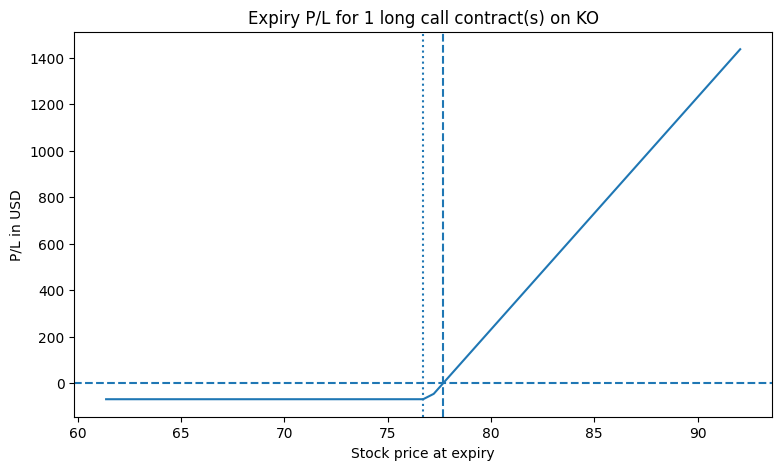

In [11]:
plt.figure(figsize=(9, 5))
plt.plot(scenario_df["stock_price_at_expiry"], scenario_df["pnl_total_usd"])
plt.axhline(0, linestyle="--")
plt.axvline(spot, linestyle=":")
plt.axvline(breakeven, linestyle="--")
plt.title(f"Expiry P/L for {contracts} long {option_type} contract(s) on {ticker}")
plt.xlabel("Stock price at expiry")
plt.ylabel("P/L in USD")
plt.show()

## Compare market chain vs model values across strikes

In [12]:
def enrich_chain_with_models(df, S, T, r, q, sigma, option_type="call", steps=200):
    out = df.copy()
    out["market_premium"] = out.apply(lambda row: clean_market_premium(row, use_mid=use_mid_price), axis=1)
    out["bs_price"] = out["strike"].apply(lambda K: bs_price(S, float(K), T, r, q, sigma, option_type))
    out["crr_eur"] = out["strike"].apply(lambda K: crr_binomial(S, float(K), T, r, q, sigma, steps=steps, option_type=option_type, american=False))
    out["crr_am"] = out["strike"].apply(lambda K: crr_binomial(S, float(K), T, r, q, sigma, steps=steps, option_type=option_type, american=True))
    out["am_minus_eur"] = out["crr_am"] - out["crr_eur"]
    out["market_minus_am"] = out["market_premium"] - out["crr_am"]
    return out

chain_modeled = enrich_chain_with_models(chain_df, spot, T_years, r, q, sigma, option_type=option_type, steps=min(crr_steps, 100))
cols_to_show = ["strike", "bid", "ask", "lastPrice", "market_premium", "bs_price", "crr_eur", "crr_am", "am_minus_eur", "market_minus_am"]
chain_modeled[cols_to_show].head(15)

,strike,bid,ask,lastPrice,market_premium,bs_price,crr_eur,crr_am,am_minus_eur,market_minus_am
0,65.0,11.45,12.10,11.26,11.775,8.979982e+00,8.979982e+00,1.172000e+01,2.740019e+00,0.054999
1,69.0,5.80,9.75,7.33,7.775,4.982231e+00,4.982197e+00,7.720001e+00,2.737804e+00,0.054999
2,71.0,4.75,7.05,5.15,5.900,2.991985e+00,2.989996e+00,5.720001e+00,2.730005e+00,0.179999
3,72.0,4.40,5.25,4.92,4.825,2.036149e+00,2.030633e+00,4.720001e+00,2.689368e+00,0.104999
4,73.0,3.60,4.20,3.83,3.900,1.192513e+00,1.183010e+00,3.720001e+00,2.536991e+00,0.179999
5,74.0,2.58,3.20,2.95,2.890,5.665779e-01,5.573942e-01,2.720001e+00,2.162607e+00,0.169999
6,75.0,1.83,2.15,2.07,1.990,2.068906e-01,2.008968e-01,1.720001e+00,1.519104e+00,0.269999
7,76.0,1.22,1.35,1.26,1.285,5.575783e-02,5.396239e-02,7.200012e-01,6.660388e-01,0.564999
8,77.0,0.66,0.72,0.68,0.690,1.080935e-02,1.015419e-02,6.903955e-02,5.888537e-02,0.620960
9,78.0,0.29,0.34,0.32,0.315,1.487099e-03,1.403016e-03,5.167681e-03,3.764665e-03,0.309832


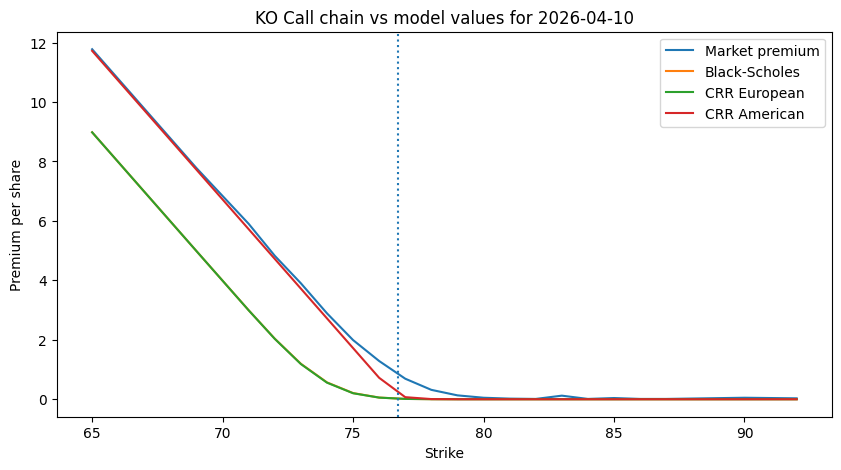

In [13]:
plt.figure(figsize=(10, 5))
subset = chain_modeled.dropna(subset=["market_premium"]).copy()

plt.plot(subset["strike"], subset["market_premium"], label="Market premium")
plt.plot(subset["strike"], subset["bs_price"], label="Black-Scholes")
plt.plot(subset["strike"], subset["crr_eur"], label="CRR European")
plt.plot(subset["strike"], subset["crr_am"], label="CRR American")
plt.axvline(spot, linestyle=":")
plt.title(f"{ticker} {option_type.capitalize()} chain vs model values for {expiry}")
plt.xlabel("Strike")
plt.ylabel("Premium per share")
plt.legend()
plt.show()

## Business explanation cell

In [14]:
result = {
    "ticker": ticker,
    "option_type": option_type,
    "expiry": expiry,
    "spot": spot,
    "strike": strike,
    "market_premium": market_premium,
    "dividend_yield": q,
    "sigma_hist": sigma,
    "T_years": T_years,
    "bs_price": bs.price,
    "crr_american_price": crr_am,
    "breakeven": breakeven,
    "contracts": contracts,
    "max_loss_usd": max_loss_usd,
    "early_exercise_premium": crr_am - crr_eur,
}

business_summary = make_business_summary(result)
print(business_summary)

- Ticker: KO- Selected contract: CALL strike 77.00, expiry 2026-04-10- Spot price is 76.72 and market premium is 0.69 per share.- Estimated dividend yield used in pricing is 269.00%.- Historical volatility estimate is 16.63% annualized.- Time to expiry is 0.014 years.- Against Black-Scholes, the market premium is richer than the model value.- Against the American CRR model, the contract trades above the model estimate.- The expiry break-even is 77.69. The stock must finish above that level at expiry for a long call to profit at expiry.- With 1 contract(s), the maximum premium at risk is about $69.00.- The American model is meaningfully above the European model, so early-exercise flexibility has value here.- Business translation: this trade is not only a view on direction, it is a view on direction, timing, and volatility.



## Risk mitigation checklist

### 1) Position sizing
Never size based only on "cheap premium". Size based on **maximum acceptable loss**.

For long options:

$$
\text{Max loss} = \text{premium per share} \times 100 \times \text{contracts}
$$

### 2) Liquidity
Check:

- bid/ask spread
- volume
- open interest

A cheap option with a very wide spread may be hard to exit.

### 3) Time decay
Short-dated long options lose value quickly. A trade can be directionally right but still lose money if the move comes too late.

### 4) Dividend effect
For dividend-paying stocks:

- European and American values may differ
- American calls may have some early-exercise value
- puts can also show meaningful American premium

### 5) Model risk
No single model is "the truth".

- Black-Scholes assumes European exercise
- binomial trees are more flexible
- actual market prices also reflect supply/demand, event risk, volatility skew, and liquidity

### 6) Trade thesis check
Before entering, write:

- **direction**: bullish or bearish
- **catalyst**: why should the stock move?
- **deadline**: why before this expiry?
- **break-even**: exact number
- **max loss**: exact number
- **exit rule**: profit target or max drawdown rule

### 7) Business interpretation
A real-world option trade is not just a bet on direction.

It is a joint bet on:

- direction
- timing
- volatility
- liquidity
- and, for dividend stocks, exercise style


In [15]:
liquidity_snapshot = pd.DataFrame({
    "field": ["bid", "ask", "spread", "volume", "openInterest"],
    "value": [
        selected_row.get("bid", np.nan),
        selected_row.get("ask", np.nan),
        (selected_row.get("ask", np.nan) - selected_row.get("bid", np.nan))
        if pd.notna(selected_row.get("ask", np.nan)) and pd.notna(selected_row.get("bid", np.nan))
        else np.nan,
        selected_row.get("volume", np.nan),
        selected_row.get("openInterest", np.nan),
    ]
})
liquidity_snapshot

,field,value
0,bid,0.66
1,ask,0.72
2,spread,0.06
3,volume,1735.00
4,openInterest,5283.00



## Suggested interpretation template for any trade

After running the notebook, summarize the trade like this:

> "I am considering a long **CALL/PUT** on **TICKER** with strike **K** and expiry **DATE**.  
> The market premium is **X** per share.  
> My model range is approximately **Y to Z** depending on Black-Scholes and binomial methods.  
> Break-even at expiry is **B**.  
> Maximum loss for **N** contract(s) is **L**.  
> The American premium is **A**, which means early exercise is / is not very important here.  
> The main risks are stock not moving enough, moving too late, implied volatility changing, and poor liquidity."



## Optional extensions

You can expand this notebook by adding:

- implied-volatility surface by strike and expiry
- event-date tracking
- realized volatility vs implied volatility
- put-call parity checks
- covered-call and protective-put analysis
- dividend ex-date monitoring



## Final note

This notebook helps apply:

- **Black-Scholes**
- **1-step binomial**
- **multi-step binomial**
- **European vs American exercise**
- **dividend effects**
- **risk mitigation**
- **business explanation**

to a live option quote pulled from `yfinance`.

The goal is not to predict the stock perfectly.  
The goal is to make **better-structured decisions with defined risk**.
